In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
# Load the dataset
df = pd.read_csv('../data/MachineLearningRating_v3.txt', sep='|', low_memory=False)

print(f"✅ Data loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head(3)

✅ Data loaded!
Shape: (1000098, 52)

Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [3]:
print("=== DATA TYPES ===")
print(df.dtypes)
print(f"\n=== SHAPE ===")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

=== DATA TYPES ===
UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth                str
IsVATRegistered                bool
Citizenship                     str
LegalType                       str
Title                           str
Language                        str
Bank                            str
AccountType                     str
MaritalStatus                   str
Gender                          str
Country                         str
Province                        str
PostalCode                    int64
MainCrestaZone                  str
SubCrestaZone                   str
ItemType                        str
mmcode                      float64
VehicleType                     str
RegistrationYear              int64
make                            str
Model                           str
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
bodytype                        str
NumberOfD

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"Columns with missing values: {len(missing_df)}")
print(missing_df.head(20))

Columns with missing values: 22
                         Missing Count  Missing %
NumberOfVehiclesInFleet        1000098     100.00
CrossBorder                     999400      99.93
CustomValueEstimate             779642      77.96
WrittenOff                      641901      64.18
Converted                       641901      64.18
Rebuilt                         641901      64.18
NewVehicle                      153295      15.33
Bank                            145961      14.59
AccountType                      40232       4.02
Gender                            9536       0.95
MaritalStatus                     8259       0.83
mmcode                             552       0.06
VehicleType                        552       0.06
make                               552       0.06
VehicleIntroDate                   552       0.06
NumberOfDoors                      552       0.06
bodytype                           552       0.06
kilowatts                          552       0.06
cubiccapacity     

In [5]:
# Key financial columns
financial_cols = ['TotalPremium', 'TotalClaims', 
                  'CalculatedPremiumPerTerm', 'SumInsured',
                  'CustomValueEstimate']

# Keep only columns that exist
financial_cols = [c for c in financial_cols if c in df.columns]

print("=== DESCRIPTIVE STATISTICS ===")
print(df[financial_cols].describe().round(2))

=== DESCRIPTIVE STATISTICS ===
       TotalPremium  TotalClaims  CalculatedPremiumPerTerm   SumInsured  \
count    1000098.00   1000098.00                1000098.00   1000098.00   
mean          61.91        64.86                    117.88    604172.73   
std          230.28      2384.07                    399.70   1508331.84   
min         -782.58    -12002.41                      0.00         0.01   
25%            0.00         0.00                      3.22      5000.00   
50%            2.18         0.00                      8.44      7500.00   
75%           21.93         0.00                     90.00    250000.00   
max        65282.60    393092.11                  74422.17  12636200.00   

       CustomValueEstimate  
count            220456.00  
mean             225531.13  
std              564515.75  
min               20000.00  
25%              135000.00  
50%              220000.00  
75%              280000.00  
max            26550000.00  


In [6]:
# Loss Ratio and Margin
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium'].replace(0, np.nan)
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

# Overall metrics
overall_loss_ratio = df['TotalClaims'].sum() / df['TotalPremium'].sum()
overall_margin = df['Margin'].sum()

print(f"=== PORTFOLIO KEY METRICS ===")
print(f"Overall Loss Ratio: {overall_loss_ratio:.4f} ({overall_loss_ratio*100:.2f}%)")
print(f"Total Portfolio Margin: R{overall_margin:,.2f}")
print(f"Total Premium Collected: R{df['TotalPremium'].sum():,.2f}")
print(f"Total Claims Paid: R{df['TotalClaims'].sum():,.2f}")

=== PORTFOLIO KEY METRICS ===
Overall Loss Ratio: 1.0477 (104.77%)
Total Portfolio Margin: R-2,955,983.47
Total Premium Collected: R61,911,562.70
Total Claims Paid: R64,867,546.17


In [7]:
if 'Province' in df.columns:
    province_stats = df.groupby('Province').agg(
        TotalPremium=('TotalPremium', 'sum'),
        TotalClaims=('TotalClaims', 'sum'),
        PolicyCount=('TotalPremium', 'count')
    ).reset_index()
    
    province_stats['LossRatio'] = (
        province_stats['TotalClaims'] / 
        province_stats['TotalPremium']
    ).round(4)
    
    province_stats['AvgPremium'] = (
        province_stats['TotalPremium'] / 
        province_stats['PolicyCount']
    ).round(2)
    
    province_stats = province_stats.sort_values('LossRatio', ascending=False)
    print("=== LOSS RATIO BY PROVINCE ===")
    print(province_stats.to_string(index=False))

=== LOSS RATIO BY PROVINCE ===
     Province  TotalPremium  TotalClaims  PolicyCount  LossRatio  AvgPremium
      Gauteng  2.405377e+07 2.939415e+07       393865     1.2220       61.07
KwaZulu-Natal  1.320908e+07 1.430138e+07       169781     1.0827       77.80
 Western Cape  9.806559e+06 1.038977e+07       170796     1.0595       57.42
   North West  7.490508e+06 5.920250e+06       143287     0.7904       52.28
   Mpumalanga  2.836292e+06 2.044675e+06        52718     0.7209       53.80
   Free State  5.213632e+05 3.549223e+05         8099     0.6808       64.37
      Limpopo  1.537324e+06 1.016477e+06        24836     0.6612       61.90
 Eastern Cape  2.140104e+06 1.356427e+06        30336     0.6338       70.55
Northern Cape  3.165581e+05 8.949051e+04         6380     0.2827       49.62


In [9]:
if 'VehicleType' in df.columns:
    vehicle_stats = df.groupby('VehicleType').agg(
        TotalPremium=('TotalPremium', 'sum'),
        TotalClaims=('TotalClaims', 'sum'),
        Count=('TotalPremium', 'count')
    ).reset_index()
    
    vehicle_stats['LossRatio'] = (
        vehicle_stats['TotalClaims'] / 
        vehicle_stats['TotalPremium']
    ).round(4)
    
    vehicle_stats = vehicle_stats.sort_values('LossRatio', ascending=False)
    print("=== LOSS RATIO BY VEHICLE TYPE ===")
    print(vehicle_stats.to_string(index=False))

=== LOSS RATIO BY VEHICLE TYPE ===
      VehicleType  TotalPremium  TotalClaims  Count  LossRatio
 Heavy Commercial  4.609479e+05 7.504746e+05   7401     1.6281
Medium Commercial  3.922746e+06 4.119867e+06  53985     1.0503
Passenger Vehicle  5.664202e+07 5.937207e+07 933598     1.0482
 Light Commercial  2.604975e+05 6.045250e+04   3897     0.2321
              Bus  5.824474e+04 7.996535e+03    665     0.1373


In [10]:
if 'Gender' in df.columns:
    gender_stats = df.groupby('Gender').agg(
        TotalPremium=('TotalPremium', 'sum'),
        TotalClaims=('TotalClaims', 'sum'),
        Count=('TotalPremium', 'count')
    ).reset_index()
    
    gender_stats['LossRatio'] = (
        gender_stats['TotalClaims'] / 
        gender_stats['TotalPremium']
    ).round(4)
    
    print("=== LOSS RATIO BY GENDER ===")
    print(gender_stats.to_string(index=False))

=== LOSS RATIO BY GENDER ===
       Gender  TotalPremium  TotalClaims  Count  LossRatio
       Female  3.044806e+05 2.502461e+05   6755     0.8219
         Male  1.580143e+06 1.396704e+06  42817     0.8839
Not specified  5.920275e+07 6.271410e+07 940990     1.0593


In [11]:
if 'TransactionMonth' in df.columns:
    df['TransactionMonth'] = pd.to_datetime(
        df['TransactionMonth'], errors='coerce'
    )
    
    monthly = df.groupby(
        df['TransactionMonth'].dt.to_period('M')
    ).agg(
        TotalPremium=('TotalPremium', 'sum'),
        TotalClaims=('TotalClaims', 'sum'),
        PolicyCount=('TotalPremium', 'count')
    ).reset_index()
    
    monthly['LossRatio'] = (
        monthly['TotalClaims'] / 
        monthly['TotalPremium']
    ).round(4)
    
    monthly['TransactionMonth'] = monthly['TransactionMonth'].astype(str)
    
    print("=== MONTHLY TRENDS ===")
    print(monthly.to_string(index=False))

=== MONTHLY TRENDS ===
TransactionMonth  TotalPremium  TotalClaims  PolicyCount  LossRatio
         2013-10  3.710635e+02 0.000000e+00           45     0.0000
         2013-11  2.130747e+04 5.058508e+04         1196     2.3741
         2013-12  4.248475e+04 9.283386e+03         1495     0.2185
         2014-01  5.408520e+04 1.243686e+04         1827     0.2299
         2014-02  6.078844e+04 6.298931e+04         2062     1.0362
         2014-03  9.857719e+04 3.227850e+05         3466     3.2744
         2014-04  2.342743e+05 3.068636e+05         6919     1.3098
         2014-05  3.759117e+05 5.180427e+05         9484     1.3781
         2014-06  4.862194e+05 5.045364e+05        11822     1.0377
         2014-07  6.092661e+05 4.289822e+05        14907     0.7041
         2014-08  9.074381e+05 6.934197e+05        19626     0.7642
         2014-09  1.237522e+06 9.089024e+05        25990     0.7345
         2014-10  1.670355e+06 1.764693e+06        33820     1.0565
         2014-11  2.80540

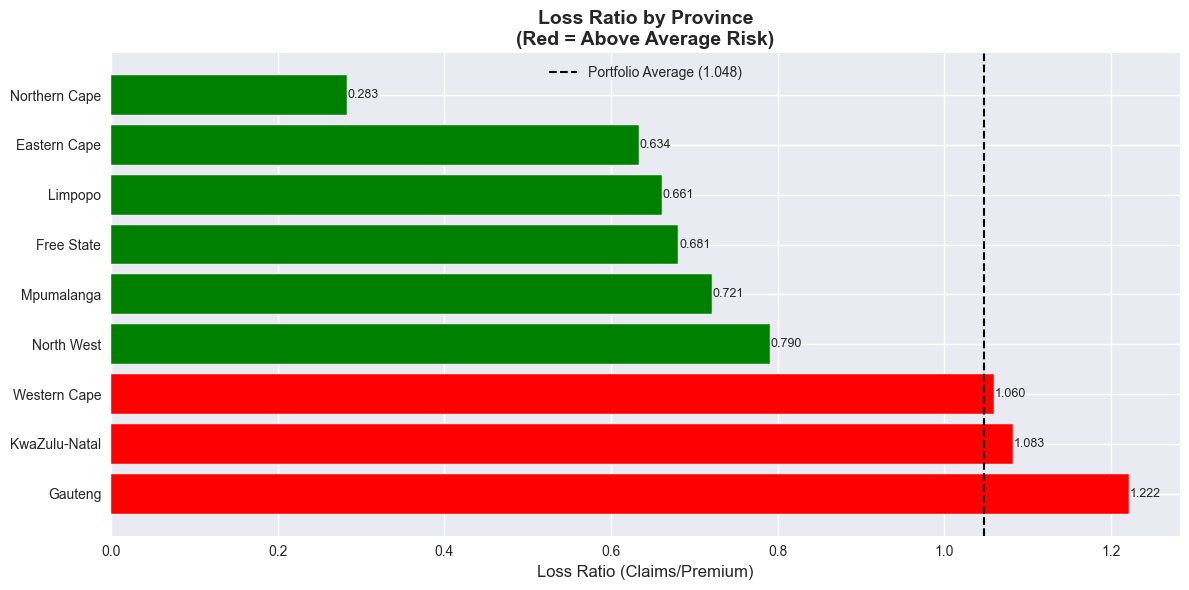

✅ Plot 1 saved!


In [12]:
if 'Province' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = ['red' if x > overall_loss_ratio else 'green' 
              for x in province_stats['LossRatio']]
    
    bars = ax.barh(province_stats['Province'], 
                   province_stats['LossRatio'],
                   color=colors, edgecolor='white')
    
    ax.axvline(overall_loss_ratio, color='black', 
               linestyle='--', linewidth=1.5,
               label=f'Portfolio Average ({overall_loss_ratio:.3f})')
    
    ax.set_title('Loss Ratio by Province\n(Red = Above Average Risk)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Loss Ratio (Claims/Premium)', fontsize=12)
    ax.legend()
    
    # Add value labels
    for bar, val in zip(bars, province_stats['LossRatio']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('../reports/loss_ratio_by_province.png', dpi=150)
    plt.show()
    print("✅ Plot 1 saved!")

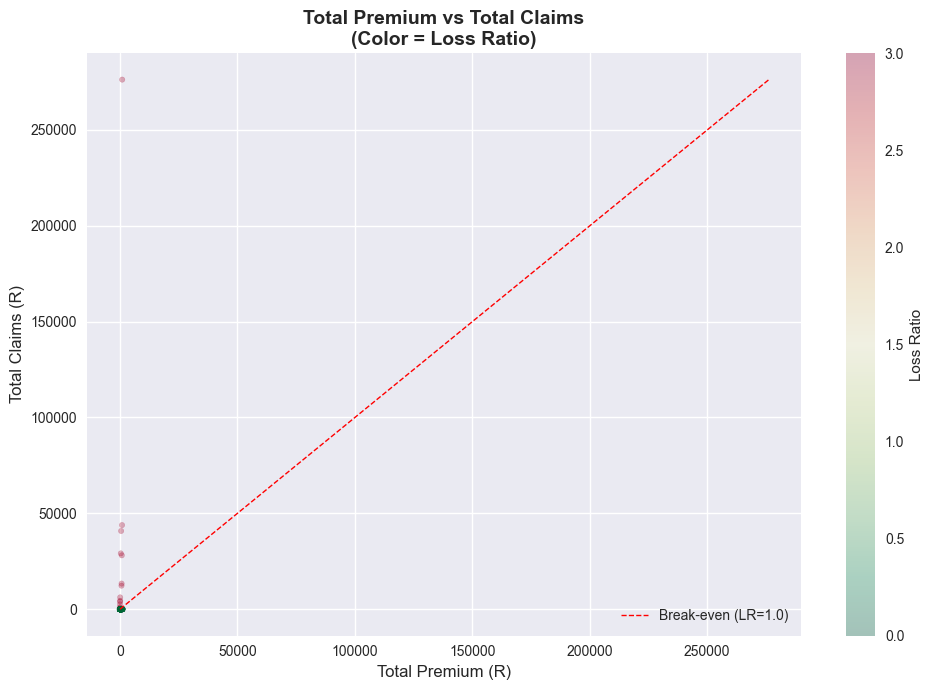

✅ Plot 2 saved!


In [13]:
fig, ax = plt.subplots(figsize=(10, 7))

# Sample for performance
sample = df.sample(min(5000, len(df)), random_state=42)

scatter = ax.scatter(
    sample['TotalPremium'],
    sample['TotalClaims'],
    alpha=0.3, s=15,
    c=sample['LossRatio'].clip(0, 3),
    cmap='RdYlGn_r'
)

plt.colorbar(scatter, label='Loss Ratio')
ax.set_title('Total Premium vs Total Claims\n(Color = Loss Ratio)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Premium (R)', fontsize=12)
ax.set_ylabel('Total Claims (R)', fontsize=12)

# Add diagonal line (loss ratio = 1)
max_val = max(sample['TotalPremium'].max(), 
              sample['TotalClaims'].max())
ax.plot([0, max_val], [0, max_val], 'r--', 
        linewidth=1, label='Break-even (LR=1.0)')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/premium_vs_claims_scatter.png', dpi=150)
plt.show()
print("✅ Plot 2 saved!")

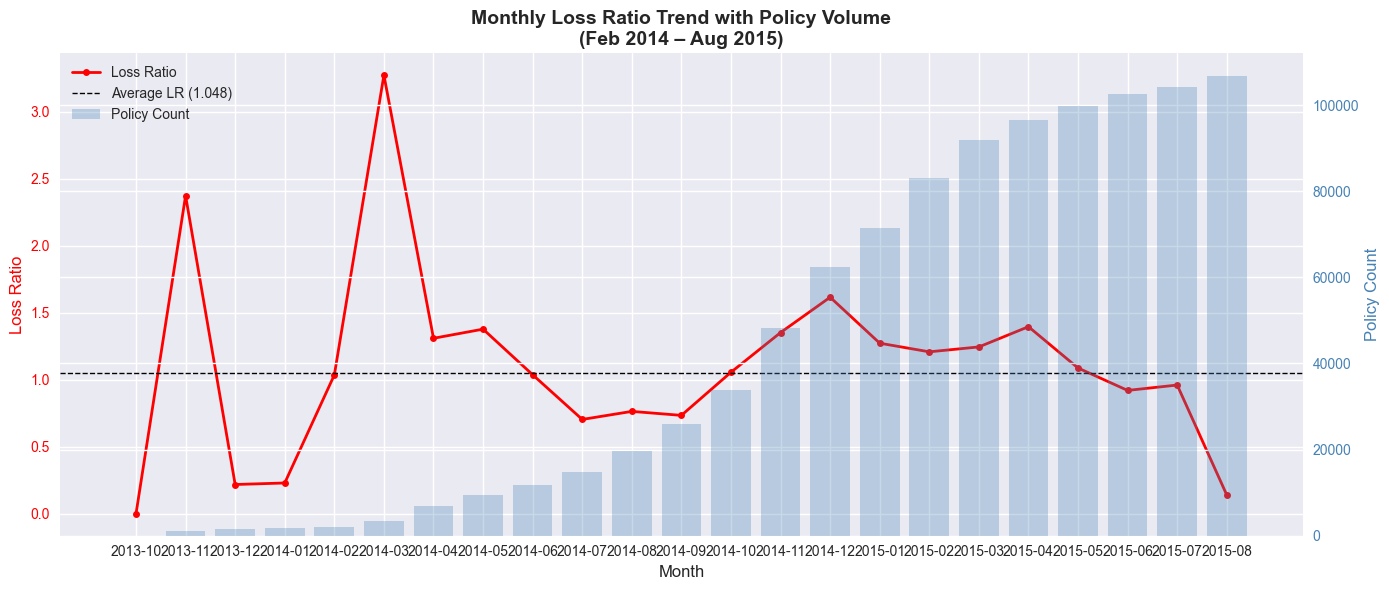

✅ Plot 3 saved!


In [14]:
if 'TransactionMonth' in df.columns:
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    ax1.plot(monthly['TransactionMonth'], 
             monthly['LossRatio'],
             color='red', linewidth=2, 
             marker='o', markersize=5,
             label='Loss Ratio')
    ax1.axhline(overall_loss_ratio, color='black',
                linestyle='--', linewidth=1,
                label=f'Average LR ({overall_loss_ratio:.3f})')
    ax1.set_ylabel('Loss Ratio', color='red', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='red')
    
    ax2 = ax1.twinx()
    ax2.bar(monthly['TransactionMonth'],
            monthly['PolicyCount'],
            alpha=0.3, color='steelblue',
            label='Policy Count')
    ax2.set_ylabel('Policy Count', color='steelblue', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='steelblue')
    
    ax1.set_title('Monthly Loss Ratio Trend with Policy Volume\n(Feb 2014 – Aug 2015)',
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Month', fontsize=12)
    plt.xticks(rotation=45)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.tight_layout()
    plt.savefig('../reports/monthly_loss_ratio_trend.png', dpi=150)
    plt.show()
    print("✅ Plot 3 saved!")

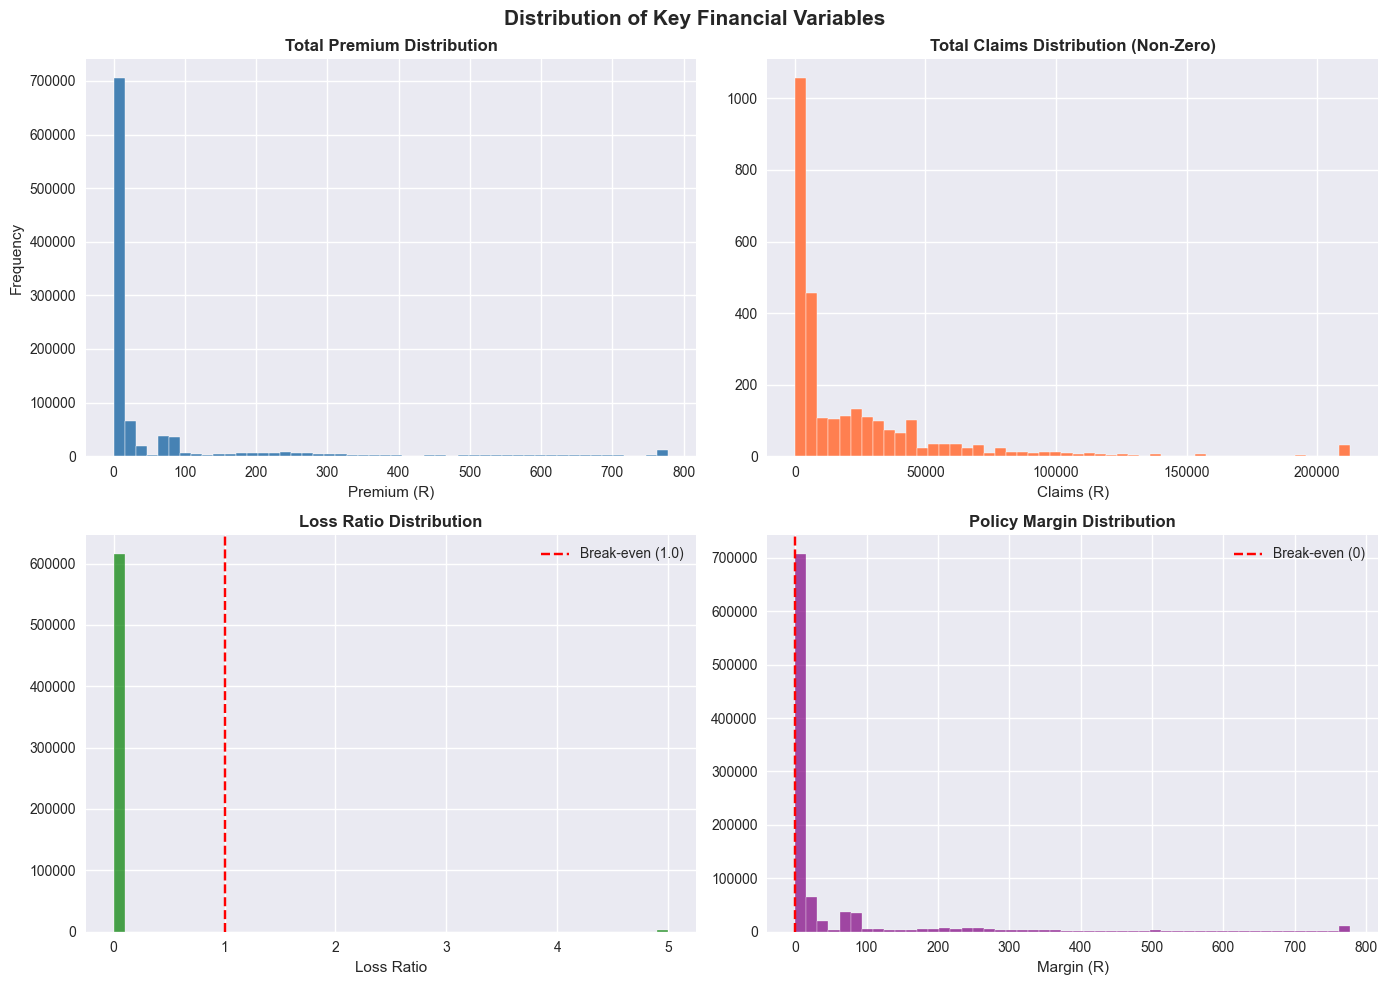

✅ Plot 4 saved!


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# TotalPremium distribution
axes[0,0].hist(df['TotalPremium'].clip(0, df['TotalPremium'].quantile(0.99)),
               bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Total Premium Distribution', fontweight='bold')
axes[0,0].set_xlabel('Premium (R)')
axes[0,0].set_ylabel('Frequency')

# TotalClaims distribution
claims_nonzero = df[df['TotalClaims'] > 0]['TotalClaims']
axes[0,1].hist(claims_nonzero.clip(0, claims_nonzero.quantile(0.99)),
               bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Total Claims Distribution (Non-Zero)',
                    fontweight='bold')
axes[0,1].set_xlabel('Claims (R)')

# Loss Ratio distribution
lr_clean = df['LossRatio'].replace([np.inf, -np.inf], np.nan).dropna()
lr_clean = lr_clean.clip(0, 5)
axes[1,0].hist(lr_clean, bins=50, 
               color='green', edgecolor='white', alpha=0.7)
axes[1,0].axvline(1.0, color='red', linestyle='--', 
                  label='Break-even (1.0)')
axes[1,0].set_title('Loss Ratio Distribution', fontweight='bold')
axes[1,0].set_xlabel('Loss Ratio')
axes[1,0].legend()

# Margin distribution
margin_clean = df['Margin'].clip(
    df['Margin'].quantile(0.01),
    df['Margin'].quantile(0.99)
)
axes[1,1].hist(margin_clean, bins=50, 
               color='purple', edgecolor='white', alpha=0.7)
axes[1,1].axvline(0, color='red', linestyle='--', 
                  label='Break-even (0)')
axes[1,1].set_title('Policy Margin Distribution', fontweight='bold')
axes[1,1].set_xlabel('Margin (R)')
axes[1,1].legend()

plt.suptitle('Distribution of Key Financial Variables',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/financial_distributions.png', dpi=150)
plt.show()
print("✅ Plot 4 saved!")

In [16]:
if 'Make' in df.columns:
    top_makes = df.groupby('Make').agg(
        AvgClaim=('TotalClaims', 'mean'),
        TotalClaims=('TotalClaims', 'sum'),
        Count=('TotalClaims', 'count')
    ).reset_index()
    
    top_makes = top_makes[top_makes['Count'] >= 50]
    top_makes = top_makes.nlargest(15, 'AvgClaim')
    
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(top_makes['Make'], 
            top_makes['AvgClaim'],
            color='darkorange', edgecolor='white')
    ax.set_title('Top 15 Vehicle Makes by Average Claim Amount\n(min 50 policies)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Average Claim Amount (R)', fontsize=12)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('../reports/top_makes_by_claim.png', dpi=150)
    plt.show()
    print("✅ Plot 5 saved!")

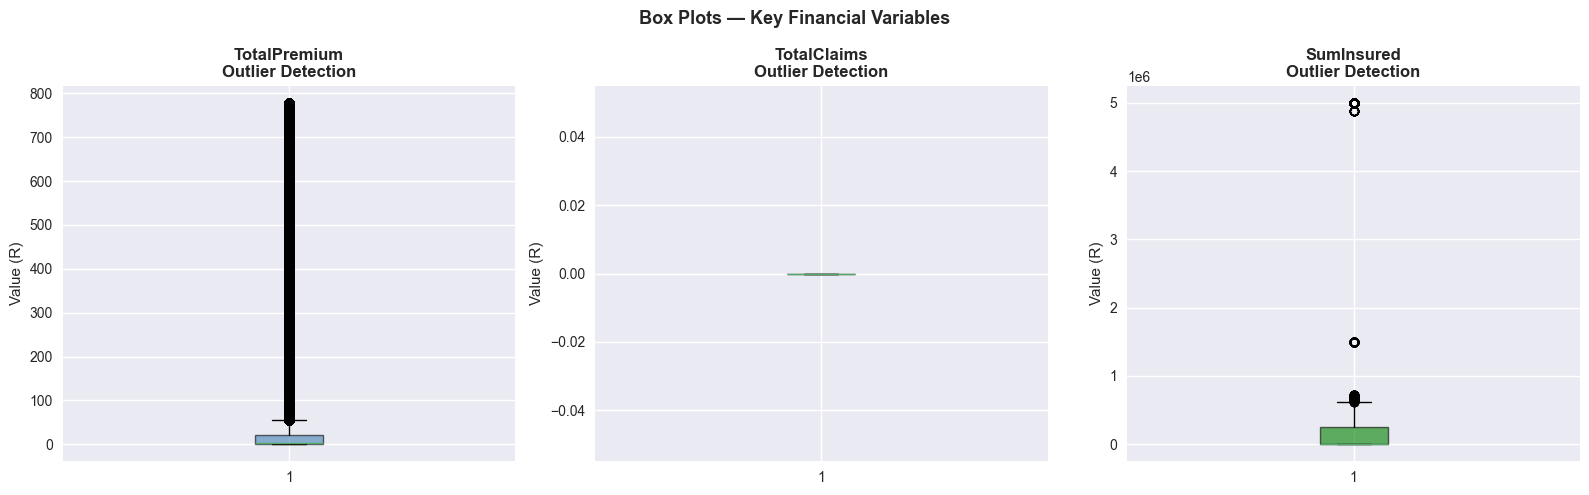

✅ Plot 6 saved!


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(
    axes,
    ['TotalPremium', 'TotalClaims', 'SumInsured'],
    ['steelblue', 'coral', 'green']
):
    if col in df.columns:
        clean = df[col].dropna()
        clean = clean.clip(0, clean.quantile(0.99))
        ax.boxplot(clean, patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.6))
        ax.set_title(f'{col}\nOutlier Detection', fontweight='bold')
        ax.set_ylabel('Value (R)')

plt.suptitle('Box Plots — Key Financial Variables',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/outlier_boxplots.png', dpi=150)
plt.show()
print("✅ Plot 6 saved!")

In [18]:
# Handle missing values
print("Handling missing values...")

# Drop columns with >50% missing
threshold = 0.5
cols_to_drop = [c for c in df.columns 
                if df[c].isnull().mean() > threshold]
print(f"Dropping {len(cols_to_drop)} columns with >50% missing: {cols_to_drop}")
df_clean = df.drop(columns=cols_to_drop)

# Fill numeric nulls with median
num_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[num_cols] = df_clean[num_cols].fillna(
    df_clean[num_cols].median()
)

# Fill categorical nulls with mode
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"\nCleaned data shape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

# Save cleaned data
df_clean.to_csv('../data/MachineLearningRating_v3_cleaned.csv', index=False)
print("✅ Cleaned data saved!")

Handling missing values...
Dropping 6 columns with >50% missing: ['CustomValueEstimate', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet']

Cleaned data shape: (1000098, 48)
Missing values remaining: 0
✅ Cleaned data saved!


In [19]:
print("""
╔══════════════════════════════════════════════════════════╗
║           EDA SUMMARY — KEY FINDINGS                   ║
╚══════════════════════════════════════════════════════════╝
""")

print(f"Dataset: {df.shape[0]:,} policies, {df.shape[1]} features")
print(f"Period: Feb 2014 – Aug 2015 (18 months)")
print(f"\n📊 FINANCIAL METRICS:")
print(f"  Overall Loss Ratio: {overall_loss_ratio:.4f}")
print(f"  Total Premium: R{df['TotalPremium'].sum():,.2f}")
print(f"  Total Claims: R{df['TotalClaims'].sum():,.2f}")
print(f"  Total Margin: R{df['Margin'].sum():,.2f}")

if 'Province' in df.columns:
    high_risk = province_stats.iloc[0]
    low_risk = province_stats.iloc[-1]
    print(f"\n📍 GEOGRAPHIC RISK:")
    print(f"  Highest risk province: {high_risk['Province']} "
          f"(LR={high_risk['LossRatio']:.3f})")
    print(f"  Lowest risk province: {low_risk['Province']} "
          f"(LR={low_risk['LossRatio']:.3f})")

print(f"\n⚠️ DATA QUALITY:")
print(f"  Columns with missing data: {len(missing_df)}")
print(f"  Columns dropped (>50% missing): {len(cols_to_drop)}")
print(f"\n✅ EDA COMPLETE!")


╔══════════════════════════════════════════════════════════╗
║           EDA SUMMARY — KEY FINDINGS                   ║
╚══════════════════════════════════════════════════════════╝

Dataset: 1,000,098 policies, 54 features
Period: Feb 2014 – Aug 2015 (18 months)

📊 FINANCIAL METRICS:
  Overall Loss Ratio: 1.0477
  Total Premium: R61,911,562.70
  Total Claims: R64,867,546.17
  Total Margin: R-2,955,983.47

📍 GEOGRAPHIC RISK:
  Highest risk province: Gauteng (LR=1.222)
  Lowest risk province: Northern Cape (LR=0.283)

⚠️ DATA QUALITY:
  Columns with missing data: 22
  Columns dropped (>50% missing): 6

✅ EDA COMPLETE!
